您可以從 [Bookshop.org](https://bookshop.org/a/98697/9781098155438) 和
[Amazon](https://www.amazon.com/_/dp/1098155432?smid=ATVPDKIKX0DER&_encoding=UTF8&tag=oreilly20-20&_encoding=UTF8&tag=greenteapre01-20&linkCode=ur2&linkId=e2a529f94920295d27ec8a06e757dc7c&camp=1789&creative=9325) 訂購《Think Python 3e》的印刷版和電子書版本。

In [1]:
from os.path import basename, exists

def download(url):
    filename = basename(url)
    if not exists(filename):
        from urllib.request import urlretrieve

        local, _ = urlretrieve(url, filename)
        print("Downloaded " + str(local))
    return filename

download('https://github.com/AllenDowney/ThinkPython/raw/v3/thinkpython.py');
download('https://github.com/AllenDowney/ThinkPython/raw/v3/diagram.py');

import thinkpython

# 變數與陳述句

在前一章中，我們使用運算子來撰寫執行算術運算的運算式。

在本章中，您將學習變數與陳述句、`import` 陳述句，以及 `print` 函式。
我也會介紹更多我們在談論程式時使用的詞彙，包括「引數」和「模組」。

## 變數

**變數**是指向一個值的名稱。
要建立變數，我們可以撰寫一個像這樣的**指派陳述句**。

In [2]:
n = 17

指派陳述句有三個部分：左邊的變數名稱、等號運算子 `=`，以及右邊的運算式。
在這個例子中，運算式是一個整數。
在下面的例子中，運算式是一個浮點數。

In [3]:
pi = 3.141592653589793

在下面的例子中，運算式是一個字串。

In [4]:
message = 'And now for something completely different'

當您執行指派陳述句時，不會有輸出。
Python 建立變數並賦予它一個值，但指派陳述句本身沒有可見的效果。
然而，在建立變數之後，您可以將它當作運算式使用。
所以我們可以像這樣顯示 `message` 的值：

In [5]:
message

'And now for something completely different'

您也可以將變數與算術運算子一起作為運算式的一部分使用。

In [6]:
n + 25

42

In [7]:
2 * pi

6.283185307179586

您也可以在呼叫函式時使用變數。

In [8]:
round(pi)

3

In [9]:
len(message)

42

## 狀態圖

在紙上表示變數的常見方式是寫出名稱，並用箭頭指向它的值。

In [10]:
import math

from diagram import make_binding, Frame

binding = make_binding("message", 'And now for something completely different')
binding2 = make_binding("n", 17)
binding3 = make_binding("pi", 3.141592653589793)

frame = Frame([binding2, binding3, binding])

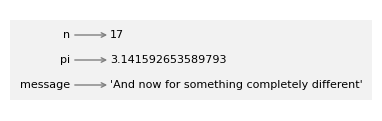

In [11]:
from diagram import diagram, adjust


width, height, x, y = [3.62, 1.01, 0.6, 0.76]
ax = diagram(width, height)
bbox = frame.draw(ax, x, y, dy=-0.25)
# adjust(x, y, bbox)

這種圖稱為**狀態圖**，因為它顯示每個變數處於什麼狀態（可以想成是變數的心理狀態）。
在整本書中，我們將使用狀態圖來表示 Python 如何儲存變數及其值的模型。

## 變數名稱

變數名稱可以任意長。它們可以包含字母和數字，但不能以數字開頭。
雖然使用大寫字母是合法的，但通常變數名稱只使用小寫字母。

變數名稱中唯一可以出現的標點符號是底線字元 `_`。它經常用於包含多個單字的名稱，例如 `your_name` 或 `airspeed_of_unladen_swallow`。

如果您給變數一個不合法的名稱，會得到語法錯誤。
名稱 `million!` 是不合法的，因為它包含標點符號。

In [12]:
%%expect SyntaxError

million! = 1000000

SyntaxError: invalid syntax (4061783710.py, line 1)

`76trombones` 是不合法的，因為它以數字開頭。

In [13]:
%%expect SyntaxError

76trombones = 'big parade'

SyntaxError: invalid decimal literal (3636686625.py, line 1)

`class` 也是不合法的，但原因可能不明顯。

In [14]:
%%expect SyntaxError

class = 'Self-Defence Against Fresh Fruit'

SyntaxError: invalid syntax (3285659805.py, line 1)

原來 `class` 是一個**關鍵字**，是用來指定程式結構的特殊單字。
關鍵字不能用作變數名稱。

以下是 Python 關鍵字的完整清單：

```
False      await      else       import     pass
None       break      except     in         raise
True       class      finally    is         return
and        continue   for        lambda     try
as         def        from       nonlocal   while
assert     del        global     not        with
async      elif       if         or         yield
```

In [15]:
from keyword import kwlist

len(kwlist)

35

您不必記住這個清單。在大多數開發環境中，
關鍵字會以不同的顏色顯示；如果您試圖將它們用作變數名稱，您會知道。

## import 陳述句

為了使用某些 Python 功能，您必須**匯入**它們。
例如，下面的陳述句匯入 `math` 模組。

In [16]:
import math

**模組**是變數和函式的集合。
math 模組提供一個稱為 `pi` 的變數，其中包含數學常數 $\pi$ 的值。
我們可以像這樣顯示它的值。

In [17]:
math.pi

3.141592653589793

要使用模組中的變數，您必須在模組名稱和變數名稱之間使用**點運算子**（`.`）。

math 模組也包含函式。
例如，`sqrt` 計算平方根。

In [18]:
math.sqrt(25)

5.0

`pow` 將一個數字提升到另一個數字的幂次。

In [19]:
math.pow(5, 2)

25.0

到目前為止，我們已經看到了兩種將數字提升到幂次的方法：我們可以使用 `math.pow` 函式或指數運算子 `**`。
兩種都可以，但運算子比函式使用得更頻繁。

## 運算式與陳述句

到目前為止，我們已經看到了幾種運算式。
運算式可以是單一值，如整數、浮點數或字串。
它也可以是值和運算子的集合。
而且它可以包含變數名稱和函式呼叫。
以下是一個包含這些元素中幾種的運算式。

In [20]:
19 + n + round(math.pi) * 2

42

我們也看到了幾種陳述句。
**陳述句**是具有效果但沒有值的程式碼單元。
例如，指派陳述句建立變數並賦予它一個值，但陳述句本身沒有值。

In [21]:
n = 17

同樣地，import 陳述句有效果 -- 它匯入模組，讓我們可以使用其中包含的變數和函式 -- 但它沒有可見的效果。

In [22]:
import math

計算運算式的值稱為**求值**。
執行陳述句稱為**執行**。

## print 函式

當您求值一個運算式時，結果會被顯示。

In [23]:
n + 1

18

但如果您求值多個運算式，只有最後一個的值會被顯示。

In [24]:
n + 2
n + 3

20

要顯示多個值，您可以使用 `print` 函式。

In [25]:
print(n+2)
print(n+3)

19
20


它也適用於浮點數和字串。

In [26]:
print('The value of pi is approximately')
print(math.pi)

The value of pi is approximately
3.141592653589793


您也可以使用由逗號分隔的運算式序列。

In [27]:
print('The value of pi is approximately', math.pi)

The value of pi is approximately 3.141592653589793


請注意 `print` 函式會在值之間放置一個空格。

## 引數

當您呼叫函式時，括弧中的運算式稱為**引數**。
通常我會解釋為什麼，但在這種情況下，術語的技術意義與該單字的常見意義幾乎沒有關係，所以我就不嘗試了。

到目前為止我們看到的一些函式只接受一個引數，例如 `int`。

In [28]:
int('101')

101

有些接受兩個，例如 `math.pow`。

In [29]:
math.pow(5, 2)

25.0

有些可以接受是可選的額外引數。
例如，`int` 可以接受第二個引數來指定數字的進位。

In [30]:
int('101', 2)

5

數字序列 `101` 在 2 進位中表示 10 進位的數字 5。

`round` 也接受可選的第二個引數，這是要四捨五入到的小數位數。

In [31]:
round(math.pi, 3)

3.142

有些函式可以接受任意數量的引數，例如 `print`。

In [32]:
print('Any', 'number', 'of', 'arguments')

Any number of arguments


如果您呼叫函式並提供太多引數，這會是 `TypeError`。

In [33]:
%%expect TypeError

float('123.0', 2)

TypeError: float expected at most 1 argument, got 2

如果您提供太少引數，這也是 `TypeError`。

In [34]:
%%expect TypeError

math.pow(2)

TypeError: pow expected 2 arguments, got 1

如果您提供的引數類型是函式無法處理的，這也是 `TypeError`。

In [35]:
%%expect TypeError

math.sqrt('123')

TypeError: must be real number, not str

當您剛開始時，這種檢查可能很煩人，但它有助於您偵測和修正錯誤。

## 註解

隨著程式變得更大更複雜，它們變得更難閱讀。
形式語言很密集，通常很難看著一段程式碼就理解它在做什麼以及為什麼。

因此，在您的程式中加入註釋來用自然語言解釋程式在做什麼是個好主意。
這些註釋稱為**註解**，它們以 `#` 符號開始。

In [36]:
# number of seconds in 42:42
seconds = 42 * 60 + 42

在這種情況下，註解單獨出現在一行上。您也可以在行尾放置註解：

In [37]:
miles = 10 / 1.61     # 10 kilometers in miles

從 `#` 到行尾的所有內容都會被忽略 --- 對程式的執行沒有影響。

當註解記錄程式碼的非明顯特性時最有用。
假設讀者能夠理解程式碼*做什麼*是合理的；解釋*為什麼*更有用。

這個註解與程式碼重複且無用：

In [38]:
v = 8     # assign 8 to v

這個註解包含程式碼中沒有的有用資訊：

In [39]:
v = 8     # velocity in miles per hour 

好的變數名稱可以減少對註解的需求，但長名稱可能使複雜運算式難以閱讀，所以這是一個權衡取捨。

## 除錯

程式中可能發生三種錯誤：語法錯誤、執行時期錯誤和語義錯誤。
區分它們有助於更快地追蹤錯誤。

* **語法錯誤**：「語法」指的是程式的結構以及關於該結構的規則。如果您的程式中任何地方有語法錯誤，Python 不會執行程式。它會立即顯示錯誤訊息。

* **執行時期錯誤**：如果您的程式中沒有語法錯誤，它可以開始執行。但如果出現問題，Python 會顯示錯誤訊息並停止。這種類型的錯誤稱為執行時期錯誤。它也稱為**例外**，因為它表示發生了例外的事情。

* **語義錯誤**：第三種錯誤是「語義」錯誤，這意味著與意義相關。如果您的程式中有語義錯誤，它會執行而不產生錯誤訊息，但它不會做您想要的事情。識別語義錯誤可能很棘手，因為它需要您透過查看程式的輸出來反推，試圖理解它在做什麼。

如我們所見，不合法的變數名稱是語法錯誤。

In [40]:
%%expect SyntaxError

million! = 1000000

SyntaxError: invalid syntax (4061783710.py, line 1)

如果您對運算子不支援的類型使用運算子，這是執行時期錯誤。

In [41]:
%%expect TypeError

'126' / 3

TypeError: unsupported operand type(s) for /: 'str' and 'int'

最後，這是語義錯誤的例子。
假設我們想要計算 `1` 和 `3` 的平均值，但我們忘記了運算順序的規則並寫了這個：

In [42]:
1 + 3 / 2

2.5

當這個運算式被求值時，它不會產生錯誤訊息，所以沒有語法錯誤或執行時期錯誤。
但結果不是 `1` 和 `3` 的平均值，所以程式不正確。
這是語義錯誤，因為程式執行了但沒有做到預期的事情。

## 詞彙表

**變數：**
指向一個值的名稱。

**指派陳述句：**
將值指派給變數的陳述句。

**狀態圖：**
一組變數及其所指向值的圖形表示。

**關鍵字：**
用來指定程式結構的特殊單字。

**import 陳述句：**
讀取模組檔案以便我們可以使用其中包含的變數和函式的陳述句。

**模組：**
包含 Python 程式碼的檔案，包括函式定義，有時還有其他陳述句。

**點運算子：**
運算子 `.`，用來存取另一個模組中的函式，方法是指定模組名稱，然後是點，然後是函式名稱。

**求值：**
按順序執行運算式中的運算以計算值。

**陳述句：**
表示命令或動作的一行或多行程式碼。

**執行：**
執行陳述句並執行它所說的。

**引數：**
呼叫函式時提供給函式的值。

**註解：**
包含在程式中的文字，提供關於程式的資訊但對其執行沒有影響。

**執行時期錯誤：**
導致程式顯示錯誤訊息並退出的錯誤。

**例外：**
在程式執行時檢測到的錯誤。

**語義錯誤：**
導致程式做錯事但不顯示錯誤訊息的錯誤。

## 練習

In [43]:
# This cell tells Jupyter to provide detailed debugging information
# when a runtime error occurs. Run it before working on the exercises.

%xmode Verbose

Exception reporting mode: Verbose


### 詢問虛擬助理

再次地，我鼓勵您使用虛擬助理來深入了解本章中的任何主題。

如果您對我列出的任何關鍵字感到好奇，您可以問「為什麼 class 是關鍵字？」或「為什麼變數名稱不能是關鍵字？」

您可能已經注意到 `int`、`float` 和 `str` 不是 Python 關鍵字。
它們是表示類型的變數，並且可以用作函式。
所以使用這些名稱作為變數或函式名稱是*合法的*，但強烈不建議這樣做。問助理「為什麼使用 int、float 和 str 作為變數名稱不好？」

同時問，「Python 中有哪些內建函式？」
如果您對其中任何一個感到好奇，請索取更多資訊。

在本章中，我們匯入了 `math` 模組並使用了它提供的一些變數和函式。問助理，「math 模組中有哪些變數和函式？」以及「除了 math 之外，哪些模組被認為是 Python 核心？」

### 練習

重複我在前一章的建議，每當您學習新功能時，您應該故意製造錯誤來看看會發生什麼。

-   我們已經看到 `n = 17` 是合法的。那 `17 = n` 呢？

-   `x = y = 1` 如何？

-   在某些語言中，每個陳述句都以分號 (`;`) 結尾。如果您在 Python 陳述句的結尾放置分號會發生什麼？

-   如果您在陳述句結尾放置句號會怎樣？

-   如果您拼錯模組名稱並嘗試匯入 `maath` 會發生什麼？

### 練習
練習使用 Python 直譯器作為計算器：

**第一部分。** 半徑為 $r$ 的球體體積為 $\frac{4}{3} \pi r^3$。
半徑為 5 的球體體積是多少？從名為 `radius` 的變數開始，然後將結果指派給名為 `volume` 的變數。顯示結果。加入註解來表示 `radius` 是以公分為單位，`volume` 是以立方公分為單位。

In [ ]:
# 解答

radius = 5                            # 以公分為單位
volume = 4 / 3 * math.pi * radius**3  # 以立方公分為單位
volume

**第二部分。** 三角學定理說，對於任何 $x$ 值，$(\cos x)^2 + (\sin x)^2 = 1$。讓我們看看對於像 42 這樣的特定 $x$ 值是否成立。

建立一個名為 `x` 的變數並賦予這個值。
然後使用 `math.cos` 和 `math.sin` 來計算 $x$ 的正弦和餘弦，以及它們平方的和。

結果應該接近 1。它可能不完全是 1，因為浮點運算不是精確的 --- 它只是近似正確的。

In [ ]:
# 解答

x = 42
math.cos(x)**2 + math.sin(x)**2

**第三部分。** 除了 `pi` 之外，`math` 模組中定義的另一個變數是 `e`，它表示自然對數的底數，在數學符號中寫作 $e$。如果您不熟悉這個值，問虛擬助理「什麼是 `math.e`？」現在讓我們用三種方式計算 $e^2$：

* 使用 `math.e` 和指數運算子 (`**`)。

* 使用 `math.pow` 將 `math.e` 提升到幂次 `2`。

* 使用 `math.exp`，它接受一個值 $x$ 作為引數，並計算 $e^x$。

您可能會注意到最後一個結果與其他兩個略有不同。
看看您能否找出哪個是正確的。

In [ ]:
# 解答

math.e ** 2

In [ ]:
# 解答

math.pow(math.e, 2)

In [ ]:
# 解答

math.exp(2)

[Think Python: 第三版](https://allendowney.github.io/ThinkPython/index.html)

版權所有 2024 [Allen B. Downey](https://allendowney.com)

程式碼授權：[MIT 授權](https://mit-license.org/)

文字授權：[創用 CC 姓名標示-非商業性-相同方式分享 4.0 國際](https://creativecommons.org/licenses/by-nc-sa/4.0/)